In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install transformers torch scikit-learn pandas numpy

In [3]:
import pandas as pd
import numpy as np
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, TrainingArguments, Trainer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset
import os

In [4]:
os.environ["WANDB_DISABLED"] = "true"

In [5]:
# Check CUDA availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("CUDA is not available. Training will use CPU.")

Using device: cuda
GPU: Tesla T4
CUDA Version: 12.8


In [6]:
# Define the path to your dataset folder
data_path = '/content/drive/MyDrive/IBMZ/phishing-email-dataset/'

# List of all CSV files to combine
csv_files = [
    'CEAS_08.csv',
    'Nazario.csv',
    'Nigerian_Fraud.csv',
    'SpamAssasin.csv'
]

In [7]:
# Load and combine all datasets
dataframes = []
for file in csv_files:
    file_path = os.path.join(data_path, file)
    print(f"Loading {file}...")
    df_temp = pd.read_csv(file_path)

    # Remove receiver column if it exists
    if 'receiver' in df_temp.columns:
        df_temp = df_temp.drop('receiver', axis=1)
        print(f"  - Removed 'receiver' column from {file}")

    print(f"  - Shape: {df_temp.shape}")
    dataframes.append(df_temp)

# Combine all dataframes
df = pd.concat(dataframes, ignore_index=True)
print(f"\nCombined dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Display first few rows
print("\nFirst few rows of combined dataset:")
print(df.head())

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Clean and prepare data
df = df.dropna(subset=['body', 'label'])
print(f"\nDataset shape after removing missing values: {df.shape}")

Loading CEAS_08.csv...
  - Removed 'receiver' column from CEAS_08.csv
  - Shape: (39154, 6)
Loading Nazario.csv...
  - Removed 'receiver' column from Nazario.csv
  - Shape: (1565, 6)
Loading Nigerian_Fraud.csv...
  - Removed 'receiver' column from Nigerian_Fraud.csv
  - Shape: (3332, 6)
Loading SpamAssasin.csv...
  - Removed 'receiver' column from SpamAssasin.csv
  - Shape: (5809, 6)

Combined dataset shape: (49860, 6)
Columns: ['sender', 'date', 'subject', 'body', 'label', 'urls']

First few rows of combined dataset:
                                              sender  \
0                   Young Esposito <Young@iworld.de>   
1                       Mok <ipline's1983@icable.ph>   
2  Daily Top 10 <Karmandeep-opengevl@universalnet...   
3                 Michael Parker <ivqrnai@pobox.com>   
4  Gretchen Suggs <externalsep1@loanofficertool.com>   

                              date  \
0  Tue, 05 Aug 2008 16:31:02 -0700   
1  Tue, 05 Aug 2008 18:31:03 -0500   
2  Tue, 05 Aug 2008 20:28

/tmp/ipykernel_4305/3778715780.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=viz_df, x='label_name', order=order, palette='Set2', ax=axes[0])
/tmp/ipykernel_4305/3778715780.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=viz_df, x='label_name', y='word_count', order=order, palette='Set2', ax=axes[2])


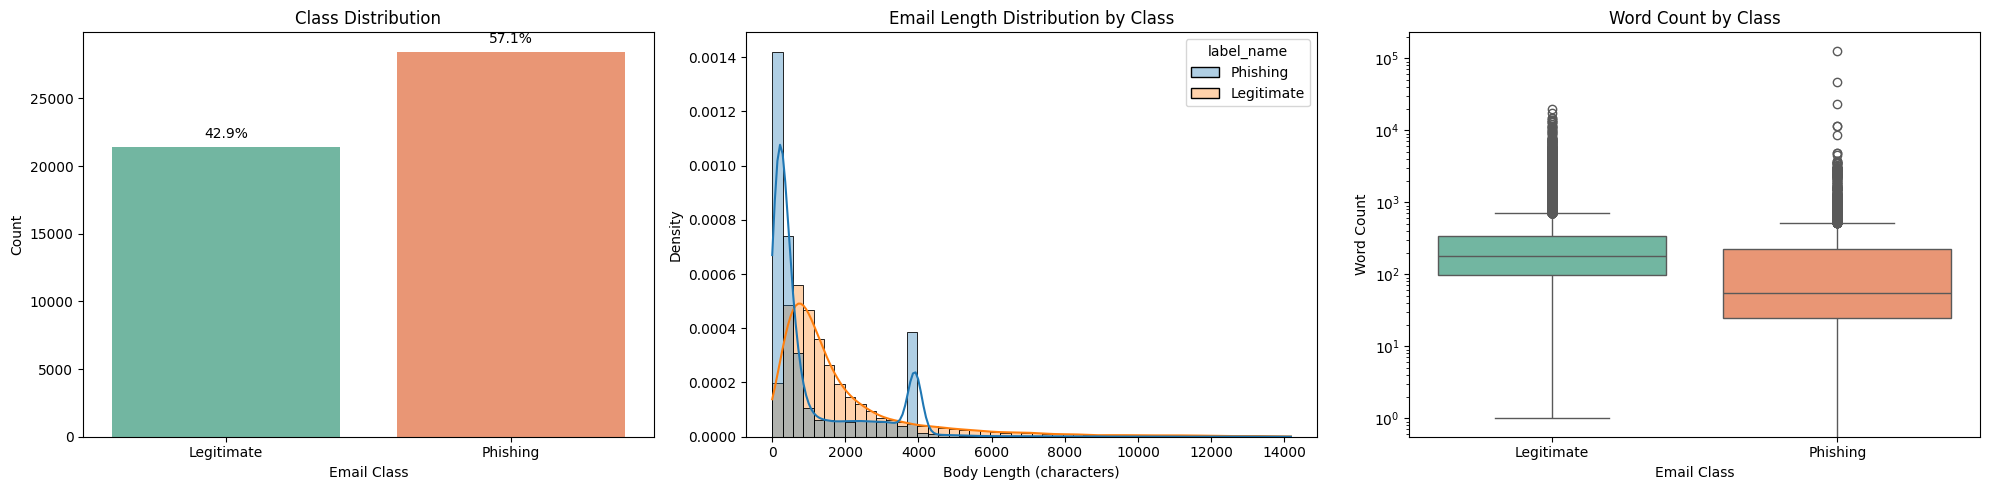

In [8]:
# Visualization: Dataset profile and class-wise length patterns
viz_df = df[['body', 'label']].dropna().copy()
viz_df['label_name'] = viz_df['label'].map({0: 'Legitimate', 1: 'Phishing'}).fillna(viz_df['label'].astype(str))
viz_df['char_length'] = viz_df['body'].str.len()
viz_df['word_count'] = viz_df['body'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1) Class distribution
order = ['Legitimate', 'Phishing']
sns.countplot(data=viz_df, x='label_name', order=order, palette='Set2', ax=axes[0])
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Email Class')
axes[0].set_ylabel('Count')

total = len(viz_df)
for patch in axes[0].patches:
    height = patch.get_height()
    if height > 0:
        axes[0].annotate(
            f"{height / total:.1%}",
            (patch.get_x() + patch.get_width() / 2, height),
            ha='center',
            va='bottom',
            fontsize=10,
            xytext=(0, 4),
            textcoords='offset points'
        )

# 2) Character-length distribution (trim extreme outliers for readability)
char_cap = viz_df['char_length'].quantile(0.99)
sns.histplot(
    data=viz_df[viz_df['char_length'] <= char_cap],
    x='char_length',
    hue='label_name',
    bins=50,
    kde=True,
    stat='density',
    common_norm=False,
    alpha=0.35,
    ax=axes[1]
    )
axes[1].set_title('Email Length Distribution by Class')
axes[1].set_xlabel('Body Length (characters)')
axes[1].set_ylabel('Density')

# 3) Word-count spread
sns.boxplot(data=viz_df, x='label_name', y='word_count', order=order, palette='Set2', ax=axes[2])
axes[2].set_title('Word Count by Class')
axes[2].set_xlabel('Email Class')
axes[2].set_ylabel('Word Count')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

In [11]:
# Split the dataset
texts = df['body'].tolist()
labels = df['label'].tolist()

train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

In [12]:
# Initialize DistilBERT tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Tokenize the data with appropriate truncation and padding
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=512)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=512)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [13]:
# Create PyTorch Dataset
class EmailDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = EmailDataset(train_encodings, train_labels)
test_dataset = EmailDataset(test_encodings, test_labels)

In [14]:
# Load pretrained DistilBERT model for binary classification
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
# Move model to GPU if available
model.to(device)
print(f"Model loaded on: {next(model.parameters()).device}")

Model loaded on: cuda:0


In [16]:
# Define training arguments with CUDA optimization
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,  # Increased for GPU
    per_device_eval_batch_size=32,   # Increased for GPU
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none",
    fp16=torch.cuda.is_available(),  # Enable mixed precision training on GPU
    dataloader_pin_memory=True,      # Speed up data transfer to GPU
    dataloader_num_workers=2,        # Parallel data loading
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [17]:
# Define metrics computation
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [18]:
# Train the model
print("Training the model...")
trainer.train()

Training the model...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.016651,0.022955,0.994986,0.994986,0.994986,0.994986
2,0.003518,0.020004,0.996189,0.996190,0.996196,0.996189
3,0.006235,0.021820,0.996290,0.996289,0.996290,0.996290


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=7479, training_loss=0.02991120584024188, metrics={'train_runtime': 1694.9586, 'train_samples_per_second': 70.598, 'train_steps_per_second': 4.412, 'total_flos': 1.5851181390575616e+16, 'train_loss': 0.02991120584024188, 'epoch': 3.0})

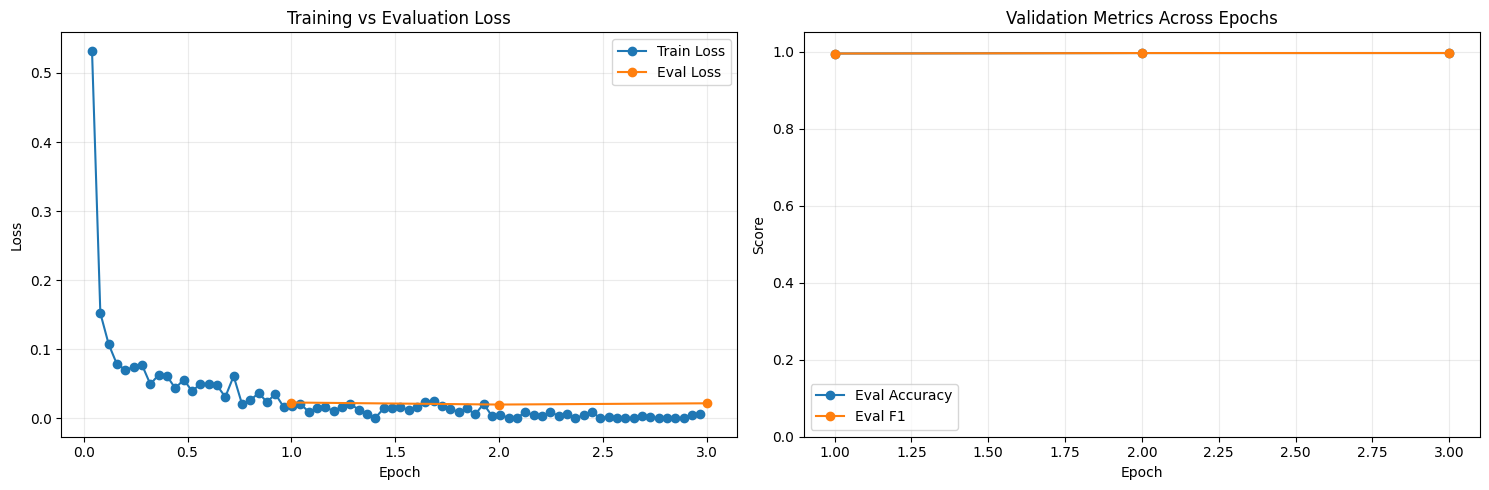

In [19]:
# Visualization: Training dynamics from Trainer log history
history_df = pd.DataFrame(trainer.state.log_history)

if history_df.empty or 'epoch' not in history_df.columns:
    print('No trainer history found. Run training first.')
else:
    train_loss = history_df.dropna(subset=['loss'])[['epoch', 'loss']].groupby('epoch', as_index=False).mean()
    eval_cols = [c for c in ['epoch', 'eval_loss', 'eval_accuracy', 'eval_f1'] if c in history_df.columns]
    eval_hist = history_df.dropna(subset=['eval_loss'])[eval_cols].drop_duplicates(subset=['epoch'])

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # 1) Loss curves
    if not train_loss.empty:
        axes[0].plot(train_loss['epoch'], train_loss['loss'], marker='o', label='Train Loss')
    if not eval_hist.empty and 'eval_loss' in eval_hist.columns:
        axes[0].plot(eval_hist['epoch'], eval_hist['eval_loss'], marker='o', label='Eval Loss')
    axes[0].set_title('Training vs Evaluation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    # 2) Validation metric curves
    if not eval_hist.empty and 'eval_accuracy' in eval_hist.columns:
        axes[1].plot(eval_hist['epoch'], eval_hist['eval_accuracy'], marker='o', label='Eval Accuracy')
    if not eval_hist.empty and 'eval_f1' in eval_hist.columns:
        axes[1].plot(eval_hist['epoch'], eval_hist['eval_f1'], marker='o', label='Eval F1')
    axes[1].set_title('Validation Metrics Across Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Score')
    axes[1].set_ylim(0, 1.05)
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


Evaluating the model...



Evaluation Results:
eval_loss: 0.0200
eval_accuracy: 0.9962
eval_f1: 0.9962
eval_precision: 0.9962
eval_recall: 0.9962
eval_runtime: 39.3150
eval_samples_per_second: 253.6440
eval_steps_per_second: 7.9360
epoch: 3.0000

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      4281
           1       1.00      1.00      1.00      5691

    accuracy                           1.00      9972
   macro avg       1.00      1.00      1.00      9972
weighted avg       1.00      1.00      1.00      9972



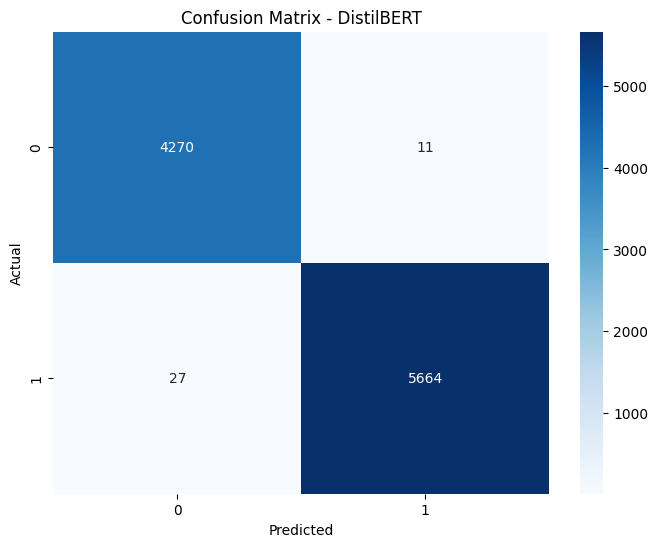

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved successfully!


In [20]:
# Evaluate the model
print("\nEvaluating the model...")
eval_results = trainer.evaluate()

print("\nEvaluation Results:")
for key, value in eval_results.items():
    print(f"{key}: {value:.4f}")

# Make predictions
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

# Print detailed classification report
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(test_labels, y_pred, zero_division=1))

# Visualize confusion matrix
conf_matrix = confusion_matrix(test_labels, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - DistilBERT')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Save the model
model.save_pretrained('./distilbert_phishing_model')
tokenizer.save_pretrained('./distilbert_phishing_model')
print("\nModel saved successfully!")

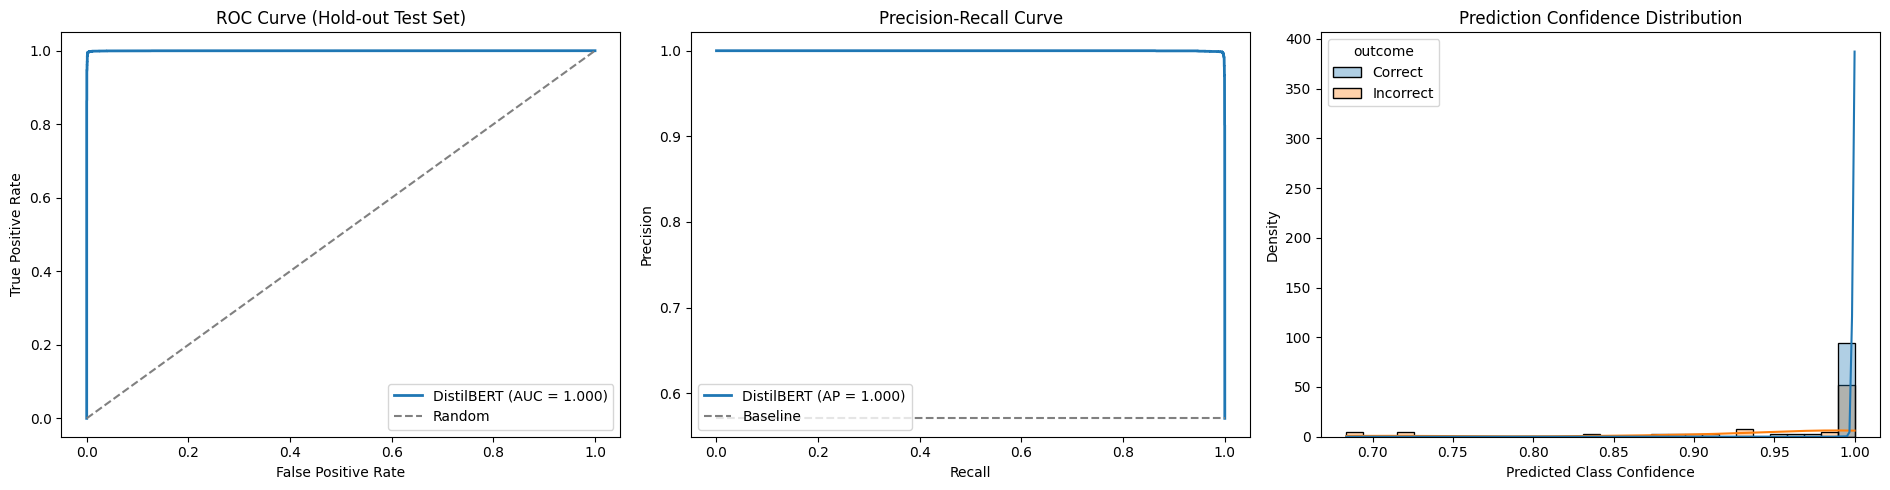

In [21]:
# Visualization: ROC, PR, and confidence diagnostics on hold-out set
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

y_true = np.array(test_labels)
logits = predictions.predictions

# Numerically stable softmax for probability extraction
logits_shifted = logits - np.max(logits, axis=1, keepdims=True)
probs = np.exp(logits_shifted) / np.exp(logits_shifted).sum(axis=1, keepdims=True)
y_score = probs[:, 1]
y_conf = probs.max(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# 1) ROC curve
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, lw=2, label=f'DistilBERT (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Random')
axes[0].set_title('ROC Curve (Hold-out Test Set)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# 2) Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_true, y_score)
avg_precision = average_precision_score(y_true, y_score)
baseline = y_true.mean()
axes[1].plot(recall, precision, lw=2, label=f'DistilBERT (AP = {avg_precision:.3f})')
axes[1].hlines(baseline, 0, 1, colors='gray', linestyles='--', label='Baseline')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')

# 3) Confidence distribution for correct vs incorrect predictions
correctness = np.where(y_pred == y_true, 'Correct', 'Incorrect')
conf_df = pd.DataFrame({'confidence': y_conf, 'outcome': correctness})
sns.histplot(
    data=conf_df,
    x='confidence',
    hue='outcome',
    bins=30,
    stat='density',
    common_norm=False,
    kde=True,
    alpha=0.35,
    ax=axes[2]
    )
axes[2].set_title('Prediction Confidence Distribution')
axes[2].set_xlabel('Predicted Class Confidence')
axes[2].set_ylabel('Density')

plt.tight_layout()
plt.show()


TESTING ON TREC_06.csv DATASET

Loading /content/drive/MyDrive/IBMZ/phishing-email-dataset/TREC_06.csv...
Attempting to load with bad line handling...
  - Successfully loaded using on_bad_lines='skip'
  - Removed 'receiver' column from TREC_06.csv
  - TREC_06 dataset shape: (16439, 6)
  - Columns: ['sender', 'date', 'subject', 'body', 'label', 'urls']

Original label dtype: float64
Converted label dtype: int64
  - Shape after removing missing values: (16381, 6)

TREC_06 Label distribution:
label
0    12393
1     3988
Name: count, dtype: int64

TREC_06 test samples: 16381

Tokenizing TREC_06 data...

Evaluating model on TREC_06 dataset...



TREC_06 EVALUATION RESULTS
Accuracy:  0.9490
Precision: 0.9486
Recall:    0.9490
F1-Score:  0.9482

TREC_06 Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97     12393
           1       0.93      0.85      0.89      3988

    accuracy                           0.95     16381
   macro avg       0.94      0.92      0.93     16381
weighted avg       0.95      0.95      0.95     16381



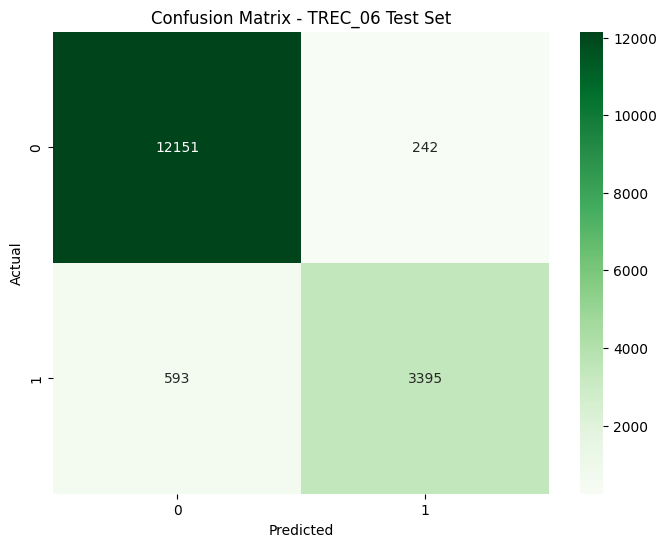


COMPARISON: Combined Dataset vs TREC_06
Combined Dataset Test Accuracy: 0.9962
TREC_06 Test Accuracy:          0.9490
Difference:                     -0.0472


In [22]:
# ============================================
# TEST ON SEPARATE TREC_06.csv DATASET
# ============================================

print("\n" + "="*60)
print("TESTING ON TREC_06.csv DATASET")
print("="*60)

# Load TREC_06.csv dataset with error handling
trec_file_path = os.path.join(data_path, 'TREC_06.csv')
print(f"\nLoading {trec_file_path}...")

# Try multiple methods to read the CSV file
try:
    # Method 1: Try with on_bad_lines='skip' (recommended for newer pandas)
    print("Attempting to load with bad line handling...")
    df_trec = pd.read_csv(trec_file_path, on_bad_lines='skip', encoding='utf-8', engine='python')
    print("  - Successfully loaded using on_bad_lines='skip'")
except Exception as e:
    print(f"  - Method 1 failed: {e}")
    try:
        # Method 2: Try with different encoding and engine
        print("Attempting with different encoding...")
        df_trec = pd.read_csv(trec_file_path, encoding='latin-1', engine='python', on_bad_lines='skip')
        print("  - Successfully loaded with latin-1 encoding")
    except Exception as e:
        print(f"  - Method 2 failed: {e}")
        try:
            # Method 3: Try reading in chunks
            print("Attempting to read in chunks...")
            chunk_size = 1000
            chunks = []
            for chunk in pd.read_csv(trec_file_path, chunksize=chunk_size, on_bad_lines='skip',
                                     encoding='utf-8', engine='python', low_memory=False):
                chunks.append(chunk)
            df_trec = pd.concat(chunks, ignore_index=True)
            print(f"  - Successfully loaded in {len(chunks)} chunks")
        except Exception as e:
            print(f"  - Method 3 failed: {e}")
            print("\nPlease check if TREC_06.csv is properly formatted.")
            raise

# Remove receiver column if it exists
if 'receiver' in df_trec.columns:
    df_trec = df_trec.drop('receiver', axis=1)
    print("  - Removed 'receiver' column from TREC_06.csv")

print(f"  - TREC_06 dataset shape: {df_trec.shape}")
print(f"  - Columns: {df_trec.columns.tolist()}")

# Clean data
df_trec = df_trec.dropna(subset=['body', 'label'])

# CRITICAL FIX: Convert float labels to integers
print(f"\nOriginal label dtype: {df_trec['label'].dtype}")
df_trec['label'] = df_trec['label'].astype(int)  # Convert float to int
print(f"Converted label dtype: {df_trec['label'].dtype}")

print(f"  - Shape after removing missing values: {df_trec.shape}")

# Check label distribution
print("\nTREC_06 Label distribution:")
print(df_trec['label'].value_counts())

# Extract texts and labels (ensure labels are integers)
trec_texts = df_trec['body'].tolist()
trec_labels = [int(label) for label in df_trec['label'].tolist()]  # Ensure int type

print(f"\nTREC_06 test samples: {len(trec_texts)}")

# Tokenize TREC_06 data
print("\nTokenizing TREC_06 data...")
trec_encodings = tokenizer(trec_texts, truncation=True, padding=True, max_length=512)

# Create TREC dataset
trec_dataset = EmailDataset(trec_encodings, trec_labels)

# Evaluate on TREC_06 dataset
print("\nEvaluating model on TREC_06 dataset...")
trec_results = trainer.predict(trec_dataset)

# Extract predictions
trec_pred = np.argmax(trec_results.predictions, axis=1)

# Calculate metrics
trec_accuracy = accuracy_score(trec_labels, trec_pred)
trec_precision, trec_recall, trec_f1, _ = precision_recall_fscore_support(
    trec_labels, trec_pred, average='weighted'
)

print("\n" + "="*60)
print("TREC_06 EVALUATION RESULTS")
print("="*60)
print(f"Accuracy:  {trec_accuracy:.4f}")
print(f"Precision: {trec_precision:.4f}")
print(f"Recall:    {trec_recall:.4f}")
print(f"F1-Score:  {trec_f1:.4f}")

# Detailed classification report for TREC_06
print("\nTREC_06 Classification Report:")
print(classification_report(trec_labels, trec_pred, zero_division=1))

# Confusion matrix for TREC_06
trec_conf_matrix = confusion_matrix(trec_labels, trec_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(trec_conf_matrix, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - TREC_06 Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\n" + "="*60)
print("COMPARISON: Combined Dataset vs TREC_06")
print("="*60)
print(f"Combined Dataset Test Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"TREC_06 Test Accuracy:          {trec_accuracy:.4f}")
print(f"Difference:                     {(trec_accuracy - eval_results['eval_accuracy']):.4f}")
print("="*60)

In [23]:
# ============================================
# SAVE MODEL TO GOOGLE DRIVE
# ============================================

import shutil
import os

print("\n" + "="*60)
print("SAVING MODEL TO GOOGLE DRIVE")
print("="*60)

# Define the Google Drive path where you want to save the model
gdrive_model_path = '/content/drive/MyDrive/IBMZ/distilbert_phishing_model'

# Create the directory if it doesn't exist
os.makedirs(gdrive_model_path, exist_ok=True)

print(f"\nSaving model to: {gdrive_model_path}")

# Method 1: Save directly to Google Drive (Recommended)
try:
    model.save_pretrained(gdrive_model_path)
    tokenizer.save_pretrained(gdrive_model_path)
    print("✓ Model and tokenizer saved successfully to Google Drive!")
except Exception as e:
    print(f"Error saving directly: {e}")

    # Method 2: Copy from local to Google Drive (Fallback)
    print("\nTrying alternative method - copying from local...")
    local_model_path = './distilbert_phishing_model_combined'

    if os.path.exists(local_model_path):
        # Copy entire directory to Google Drive
        if os.path.exists(gdrive_model_path):
            shutil.rmtree(gdrive_model_path)
        shutil.copytree(local_model_path, gdrive_model_path)
        print("✓ Model copied to Google Drive successfully!")
    else:
        print("✗ Local model directory not found!")

# Verify the files were saved
if os.path.exists(gdrive_model_path):
    saved_files = os.listdir(gdrive_model_path)
    print(f"\nFiles saved in Google Drive ({len(saved_files)} files):")
    for file in saved_files:
        file_size = os.path.getsize(os.path.join(gdrive_model_path, file)) / (1024 * 1024)  # Convert to MB
        print(f"  - {file} ({file_size:.2f} MB)")

    print("\n✓ Model is now safely stored in your Google Drive!")
    print(f"  Location: {gdrive_model_path}")
else:
    print("\n✗ Failed to save model to Google Drive!")

print("="*60)

# Optional: Save training results summary
summary_path = os.path.join(gdrive_model_path, 'training_summary.txt')
with open(summary_path, 'w') as f:
    f.write("="*60 + "\n")
    f.write("PHISHING EMAIL DETECTION MODEL - TRAINING SUMMARY\n")
    f.write("="*60 + "\n\n")
    f.write(f"Model: DistilBERT\n")
    f.write(f"Training Date: {pd.Timestamp.now()}\n\n")
    f.write(f"Combined Dataset Test Accuracy: {eval_results['eval_accuracy']:.4f}\n")
    f.write(f"Combined Dataset Test F1-Score: {eval_results['eval_f1']:.4f}\n")
    f.write(f"Combined Dataset Test Precision: {eval_results['eval_precision']:.4f}\n")
    f.write(f"Combined Dataset Test Recall: {eval_results['eval_recall']:.4f}\n\n")
    f.write(f"Total Training Samples: {len(train_texts)}\n")
    f.write(f"Total Testing Samples: {len(test_texts)}\n")
    f.write("="*60 + "\n")

print(f"\n✓ Training summary saved to: {summary_path}")


SAVING MODEL TO GOOGLE DRIVE

Saving model to: /content/drive/MyDrive/IBMZ/distilbert_phishing_model


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Model and tokenizer saved successfully to Google Drive!

Files saved in Google Drive (7 files):
  - config.json (0.00 MB)
  - model.safetensors (255.43 MB)
  - tokenizer_config.json (0.00 MB)
  - special_tokens_map.json (0.00 MB)
  - vocab.txt (0.22 MB)
  - training_summary.txt (0.00 MB)
  - tokenizer.json (0.68 MB)

✓ Model is now safely stored in your Google Drive!
  Location: /content/drive/MyDrive/IBMZ/distilbert_phishing_model

✓ Training summary saved to: /content/drive/MyDrive/IBMZ/distilbert_phishing_model/training_summary.txt
